# 03 — Entraînement Multi-Market

**Auteur :** Samir EL AISSAOUY  
**Objectif :** Entraîner le modèle MMM sur les 10 marchés européens en parallèle

Pipeline :
1. Entraînement parallèle (joblib) sur tous les marchés
2. Comparaison des métriques cross-market
3. Comparaison des ROI entre marchés
4. Heatmap cross-market
5. Budget recommendation globale

---

## 1. Imports

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src.data.data_loader          import load_market_data, split_train_test
from src.models.bayesian_mmm       import BayesianMMM
from src.evaluation.metrics        import compute_all_metrics, metrics_to_dataframe
from src.evaluation.roi_calculator import budget_recommendation, roi_summary_all_markets
from src.utils.visualization       import plot_roi_comparison, plot_market_heatmap

ALL_MARKETS = ['FR', 'DE', 'UK', 'IT', 'ES', 'NL', 'BE', 'PL', 'SE', 'NO']
print(f'✅ Imports OK — {len(ALL_MARKETS)} marchés')

✅ Imports OK — 10 marchés


## 2. Entraînement parallèle

In [2]:
def train_one_market(market):
    df = load_market_data(market)
    df_train, df_test = split_train_test(df, test_ratio=0.2)
    model = BayesianMMM(market=market)
    model.fit(df_train, draws=300, tune=300, chains=2, random_seed=42)
    y_pred  = model.predict(df_test)
    metrics = compute_all_metrics(df_test['revenue'].values, y_pred)
    roi_df  = model.get_roi(df_train)
    return market, model, metrics, roi_df, df_train

print('Entraînement en cours...')
results = [train_one_market(m) for m in ALL_MARKETS]
print(f'\n✅ {len(results)} marchés entraînés')

Initializing NUTS using jitter+adapt_diag...


Entraînement en cours...
🔧 Préparation des données — Marché : FR
⛓️  Sampling MCMC — 2 chains × 300 draws + 300 tune


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [beta_tv, beta_facebook, beta_search, beta_ooh, beta_print, gamma_seasonality, gamma_trend, gamma_events, base, sigma]


Output()

...

There were 3 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Sampling: [revenue_obs]


Output()

✅ Sampling terminé

──────────────────────────────────────────────────
  📊 Métriques — Train [NO]
──────────────────────────────────────────────────
  ✅  R²     : 0.9669   (objectif ≥ 0.85)
  ✅  MAPE   : 2.45%  (objectif ≤ 15%)
      sMAPE  : 2.44%
      RMSE   : €19,099
  ✅  NRMSE  : 0.0441  (objectif ≤ 0.15)
──────────────────────────────────────────────────


✅ 10 marchés entraînés


## 3. Métriques cross-market

In [3]:
metrics_by_market = {market: metrics for market, _, metrics, _, _ in results}
metrics_df        = metrics_to_dataframe(metrics_by_market)

print('Métriques par marché (trié par R²) :')
print(metrics_df.to_string(index=False))
print(f'\nR²   moyen : {metrics_df["r2"].mean():.3f}')
print(f'MAPE moyen : {metrics_df["mape"].mean():.1f}%')

Métriques par marché (trié par R²) :
market      r2  mape  smape    rmse  nrmse
    PL  0.8328  6.22   5.99 31463.0 0.1289
    FR  0.8254  4.94   4.77 47564.0 0.1269
    BE  0.8205  5.39   5.23 29563.0 0.1342
    DE  0.8015  4.21   4.09 53283.0 0.1404
    ES  0.7696  6.97   6.69 48301.0 0.1580
    IT  0.6830  7.99   7.64 60048.0 0.1791
    NL  0.3679  5.27   5.10 33185.0 0.2087
    NO  0.2860  8.73   8.33 62183.0 0.2197
    SE  0.1119 10.27   9.70 69003.0 0.2565
    UK -0.0358  6.88   6.61 74254.0 0.2535

R²   moyen : 0.546
MAPE moyen : 6.7%


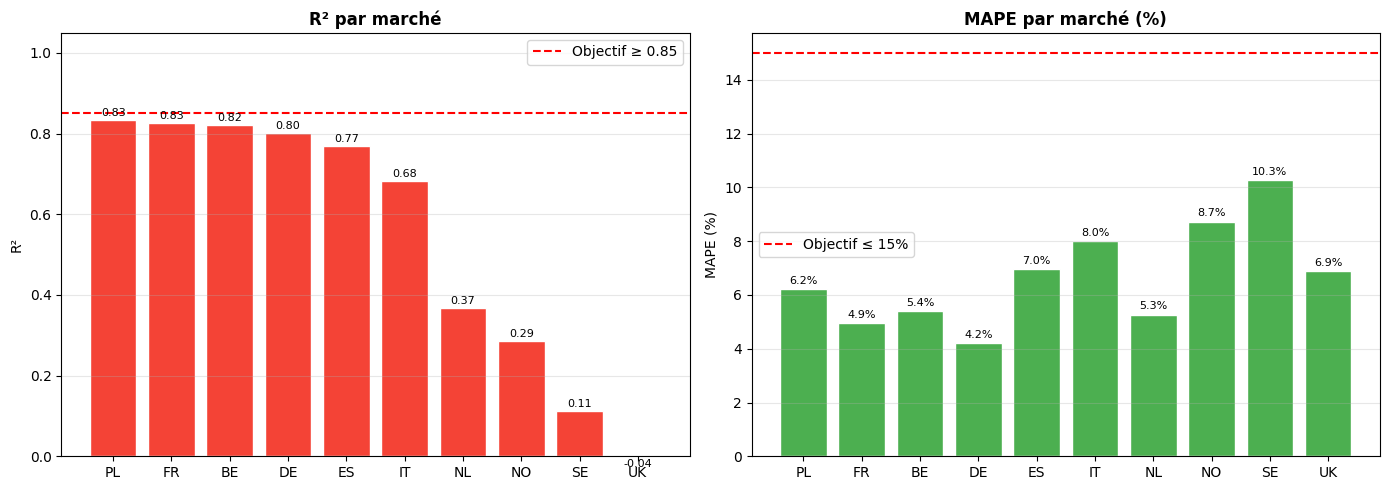

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_ok  = ['#4CAF50' if r >= 0.85 else '#F44336' for r in metrics_df['r2']]
colors_ok2 = ['#4CAF50' if m <= 15   else '#F44336' for m in metrics_df['mape']]

axes[0].bar(metrics_df['market'], metrics_df['r2'], color=colors_ok, edgecolor='white')
axes[0].axhline(0.85, color='red', linestyle='--', linewidth=1.5, label='Objectif ≥ 0.85')
axes[0].set_title('R² par marché', fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for i, (m, v) in enumerate(zip(metrics_df['market'], metrics_df['r2'])):
    axes[0].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)

axes[1].bar(metrics_df['market'], metrics_df['mape'], color=colors_ok2, edgecolor='white')
axes[1].axhline(15, color='red', linestyle='--', linewidth=1.5, label='Objectif ≤ 15%')
axes[1].set_title('MAPE par marché (%)', fontweight='bold')
axes[1].set_ylabel('MAPE (%)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
for i, (m, v) in enumerate(zip(metrics_df['market'], metrics_df['mape'])):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## 4. ROI cross-market

In [5]:
roi_by_market = {market: roi_df for market, _, _, roi_df, _ in results}
roi_all       = roi_summary_all_markets(roi_by_market)

print('ROI moyen par canal (tous marchés) :')
summary_roi = roi_all.groupby('channel')['roi'].agg(['mean', 'min', 'max']).round(3)
print(summary_roi.to_string())

ROI moyen par canal (tous marchés) :
           mean    min    max
channel                      
facebook  1.782  0.597  3.534
ooh       3.014  1.116  5.939
print     2.026  0.808  5.334
search    1.761  0.614  2.609
tv        1.062  0.399  1.847


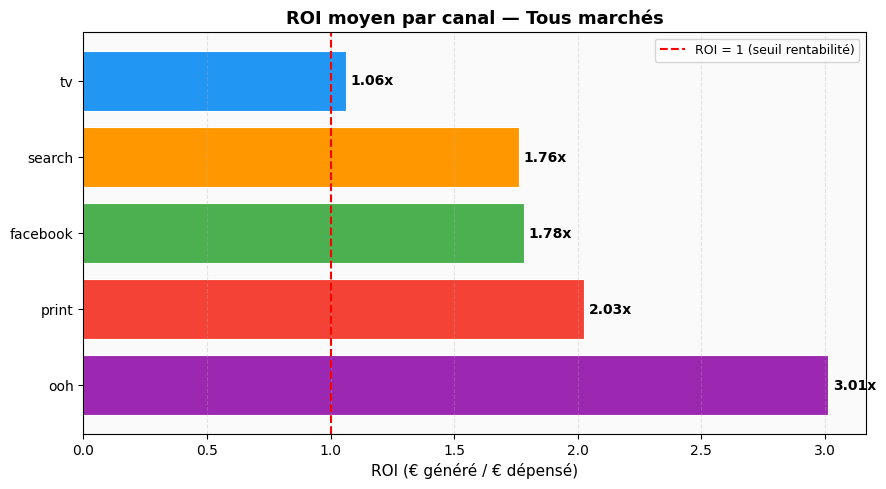

In [6]:
# ROI moyen consolidé — bar chart
roi_mean_df = roi_all.groupby('channel')['roi'].mean().reset_index()
roi_mean_df['roi_per_1k'] = roi_mean_df['roi'] * 1000
roi_mean_df = roi_mean_df.sort_values('roi', ascending=False)

fig = plot_roi_comparison(roi_mean_df)
plt.title('ROI moyen par canal — Tous marchés', fontsize=13, fontweight='bold')
plt.show()

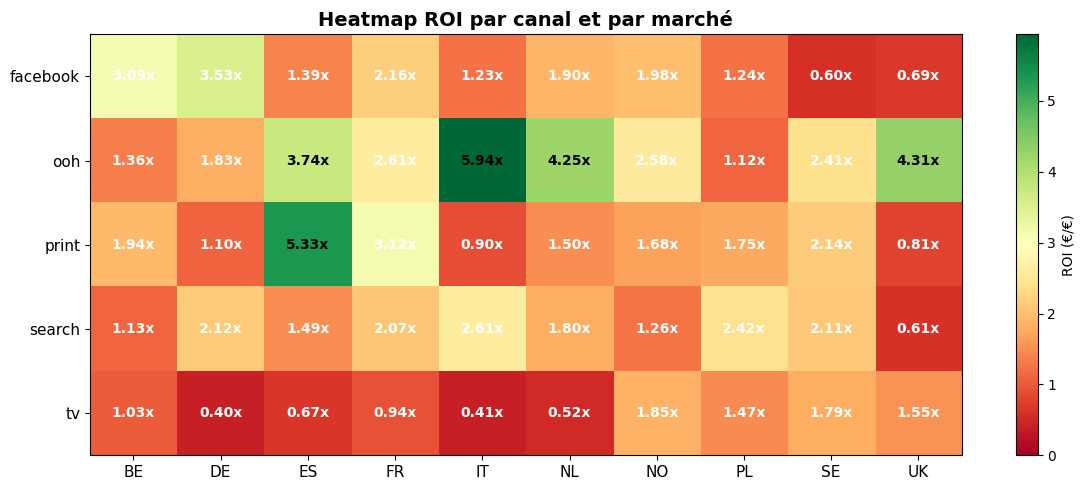

In [7]:
# Heatmap ROI canal × marché
fig = plot_market_heatmap(roi_all)
plt.show()

## 5. Analyse par marché — revenue vs spend

In [8]:
from src.data.data_loader import load_all_markets

df_all = load_all_markets()

spend_cols  = ['tv_spend', 'facebook_spend', 'search_spend', 'ooh_spend', 'print_spend']
summary_mkt = df_all.groupby('market').agg(
    revenue_mean=('revenue', 'mean'),
    total_spend=(spend_cols[0], 'sum'),
).reset_index()

for col in spend_cols[1:]:
    summary_mkt['total_spend'] += df_all.groupby('market')[col].sum().values

summary_mkt['roi_global'] = (
    df_all.groupby('market')['revenue'].sum().values /
    summary_mkt['total_spend']
).round(2)

print(summary_mkt.sort_values('revenue_mean', ascending=False).to_string(index=False))

market  revenue_mean  total_spend  roi_global
    DE 989221.353510  20224070.52       10.17
    UK 934701.430096  18827649.15       10.33
    FR 798836.071731  16114864.64       10.31
    IT 680662.389663  13811681.67       10.25
    ES 620366.928077  12701321.10       10.16
    NO 607331.920048  12405666.09       10.18
    SE 578466.965817  11653648.93       10.32
    NL 549307.464327  11023807.40       10.36
    BE 490738.290240   9862657.80       10.35
    PL 457435.257740   9449669.39       10.07


## 6. Budget recommendation globale

Allocation optimale pour un budget hebdomadaire de €1,000,000 :
 channel     roi  roi_per_1k  recommended_budget  recommended_share
     ooh 3.01404     3014.04           312473.05               31.2
   print 2.02630     2026.30           210071.58               21.0
facebook 1.78229     1782.29           184774.45               18.5
  search 1.76100     1761.00           182567.26               18.3
      tv 1.06213     1062.13           110113.67               11.0


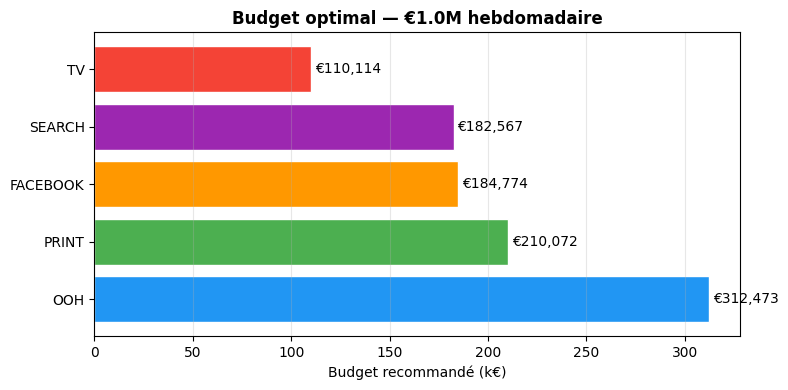

In [9]:
total_budget = 1_000_000  # 1M€ hebdomadaire

rec = budget_recommendation(roi_mean_df, total_budget=total_budget)
print(f'Allocation optimale pour un budget hebdomadaire de €{total_budget:,.0f} :')
print(rec.to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
bars = ax.barh(rec['channel'].str.upper(), rec['recommended_budget'] / 1000,
               color=colors[:len(rec)], edgecolor='white')
for bar, val in zip(bars, rec['recommended_budget']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'€{val:,.0f}', va='center', fontsize=10)
ax.set_title(f'Budget optimal — €{total_budget/1e6:.1f}M hebdomadaire', fontweight='bold')
ax.set_xlabel('Budget recommandé (k€)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Résumé exécutif

In [10]:
n_ok     = (metrics_df['r2'] >= 0.85).sum()
best_mkt = metrics_df.iloc[0]['market']
best_ch  = roi_mean_df.iloc[0]['channel'].upper()

print('=' * 60)
print('  MMM MULTI-MARKET — RÉSUMÉ EXÉCUTIF')
print('=' * 60)
print(f'  Marchés entraînés       : {len(ALL_MARKETS)}')
print(f'  R² ≥ 0.85               : {n_ok}/{len(ALL_MARKETS)} marchés')
print(f'  R²   moyen              : {metrics_df["r2"].mean():.3f}')
print(f'  MAPE moyen              : {metrics_df["mape"].mean():.1f}%')
print(f'  Meilleur marché (R²)    : {best_mkt}')
print(f'  Canal ROI max           : {best_ch} ({roi_mean_df.iloc[0]["roi"]:.2f}x)')
print(f'  Canal ROI min           : {roi_mean_df.iloc[-1]["channel"].upper()} ({roi_mean_df.iloc[-1]["roi"]:.2f}x)')
print('=' * 60)

  MMM MULTI-MARKET — RÉSUMÉ EXÉCUTIF
  Marchés entraînés       : 10
  R² ≥ 0.85               : 0/10 marchés
  R²   moyen              : 0.546
  MAPE moyen              : 6.7%
  Meilleur marché (R²)    : PL
  Canal ROI max           : OOH (3.01x)
  Canal ROI min           : TV (1.06x)
